## Imports

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")

from preprocessing import (
    run_preprocessing,
    apply_activity_category,
    ACTIVITY_CATEGORY_MAP,
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## Pipeline

In [2]:
data_path = "../data/raw/"

logs = run_preprocessing(data_path)

print("Shape:", logs.shape)
logs.head()

Shape: (11176039, 6)


,id_student,date,activity_type,sum_click,final_result,activity_category
0,6516,-23,oucontent,1,Pass,StudyMaterial
1,6516,-23,oucontent,16,Pass,StudyMaterial
2,6516,-23,oucontent,1,Pass,StudyMaterial
3,6516,-23,oucontent,5,Pass,StudyMaterial
4,6516,-23,subpage,2,Pass,StudyMaterial


## Verify Columns

In [3]:
print("Columns:", logs.columns.tolist())
print()
print("Dtypes:")
print(logs.dtypes)

Columns: ['id_student', 'date', 'activity_type', 'sum_click', 'final_result', 'activity_category']

Dtypes:
id_student            int64
date                  int64
activity_type        object
sum_click             int64
final_result         object
activity_category    object
dtype: object


## Label Distribution 

In [4]:
print("Final result distribution:")
print(logs["final_result"].value_counts())
print()
pct = logs["final_result"].value_counts(normalize=True) * 100
print("Percentages:")
print(pct.round(1))

Final result distribution:
final_result
Pass    9584599
Fail    1591440
Name: count, dtype: int64

Percentages:
final_result
Pass    85.8
Fail    14.2
Name: proportion, dtype: float64


## Activity Category Mapping

In [5]:
print("Category mapping used:")
print("-" * 40)
for activity, category in sorted(ACTIVITY_CATEGORY_MAP.items()):
    print(f"  {activity:<20} →  {category}")

Category mapping used:
----------------------------------------
  dataplus             →  DataTool
  dualpane             →  Navigation
  externalquiz         →  Quiz
  folder               →  StudyMaterial
  forumng              →  Discussion
  glossary             →  Discussion
  homepage             →  Navigation
  htmlactivity         →  StudyMaterial
  oucollaborate        →  Discussion
  oucontent            →  StudyMaterial
  ouelluminate         →  Discussion
  ouwiki               →  Discussion
  page                 →  StudyMaterial
  questionnaire        →  Quiz
  quiz                 →  Quiz
  repeatactivity       →  Quiz
  resource             →  StudyMaterial
  sharedsubpage        →  StudyMaterial
  subpage              →  StudyMaterial
  url                  →  External


## Category Distribution

In [6]:
cat_counts = logs["activity_category"].value_counts()
print("Activity category counts:")
print(cat_counts)
print()
print("Activity category percentages:")
print((cat_counts / len(logs) * 100).round(2))

Activity category counts:
activity_category
StudyMaterial    4971398
Discussion       2822527
Navigation       1834503
Quiz             1113269
External          419945
DataTool           14397
Name: count, dtype: int64

Activity category percentages:
activity_category
StudyMaterial    44.48
Discussion       25.26
Navigation       16.41
Quiz              9.96
External          3.76
DataTool          0.13
Name: count, dtype: float64


C:\Users\Samridhaa\AppData\Local\Temp\ipykernel_4112\3537173424.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


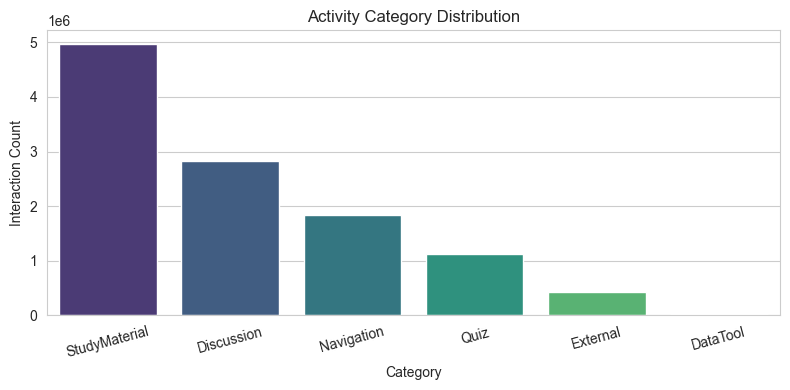

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=cat_counts.index,
    y=cat_counts.values,
    palette="viridis"
)
plt.title("Activity Category Distribution")
plt.xlabel("Category")
plt.ylabel("Interaction Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../results/figures/activity_category_distribution.png", dpi=150)
plt.show()

## Category vs Performance

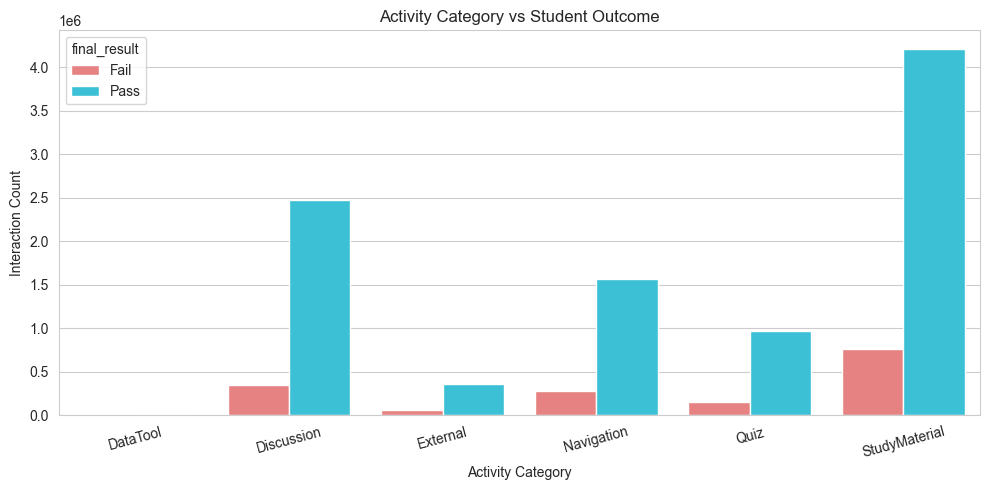

In [8]:
cat_result = (
    logs.groupby(["activity_category", "final_result"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=cat_result,
    x="activity_category",
    y="count",
    hue="final_result",
    palette={"Pass": "#22d3ee", "Fail": "#f87171"}
)
plt.title("Activity Category vs Student Outcome")
plt.xlabel("Activity Category")
plt.ylabel("Interaction Count")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../results/figures/category_vs_performance.png", dpi=150)
plt.show()

## Check: any unmapped activity types?

In [9]:
unknown_rows = logs[logs["activity_category"] == "Unknown"]
print(f"Unknown category rows: {len(unknown_rows)}")
if len(unknown_rows) > 0:
    print("\nUnique activity_types that mapped to Unknown:")
    print(unknown_rows["activity_type"].unique())

Unknown category rows: 0


## Sample rows with both columns

In [10]:
logs[["id_student", "date", "activity_type", "activity_category", "sum_click", "final_result"]].head(15)

,id_student,date,activity_type,activity_category,sum_click,final_result
0,6516,-23,oucontent,StudyMaterial,1,Pass
1,6516,-23,oucontent,StudyMaterial,16,Pass
2,6516,-23,oucontent,StudyMaterial,1,Pass
3,6516,-23,oucontent,StudyMaterial,5,Pass
4,6516,-23,subpage,StudyMaterial,2,Pass
5,6516,-23,homepage,Navigation,3,Pass
6,6516,-22,oucontent,StudyMaterial,13,Pass
7,6516,-22,forumng,Discussion,16,Pass
8,6516,-22,forumng,Discussion,17,Pass
9,6516,-22,resource,StudyMaterial,2,Pass


## Save clean_logs.csv

In [11]:
output_path = "../data/processed/clean_logs.csv"
logs.to_csv(output_path, index=False)
print(f"Saved {len(logs):,} rows to {output_path}")
print(f"Columns: {logs.columns.tolist()}")

Saved 11,176,039 rows to ../data/processed/clean_logs.csv
Columns: ['id_student', 'date', 'activity_type', 'sum_click', 'final_result', 'activity_category']


In [ ]:
logs = pd.read_csv("../data/processed/clean_logs.csv")
print(logs.shape)
print(logs["activity_category"].value_counts())

(11176039, 6)
activity_category
StudyMaterial    4971398
Discussion       2822527
Navigation       1834503
Quiz             1113269
External          419945
DataTool           14397
Name: count, dtype: int64
